In [1]:
import os
import pandas as pd
import numpy as np
import boto3
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics as skm
import datetime as dt
import boto3
import pickle
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
import warnings
# Suppress PerformanceWarning
warnings.filterwarnings('ignore')

try:
    import catboost as cb
except:
    ! pip install catboost

In [2]:
print(f'Latest run date: {dt.datetime.now()}')

Latest run date: 2024-03-15 22:27:14.708587


### Functions

In [3]:
def show_distribution(df, str_col):
    int_n = df.shape[0]
    flt_min = df[str_col].min()
    flt_max = df[str_col].max()
    flt_mean = df[str_col].mean()
    flt_sd = df[str_col].std()
    flt_mdn = df[str_col].median()
    str_title = f"""
    Distribution of {str_col} (N = {int_n})
    Min = {flt_min:0.4f}; Max = {flt_max:0.4f}; Mean = {flt_mean:0.4f}; SD = {flt_sd:0.4f}; Mdn = {flt_mdn:0.4f}
    """
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel(str_col)
    sns.kdeplot(list(df[str_col]), ax=ax)
    plt.show()

In [4]:
def visualize_relation(df, str_x):
    flt_r, flt_p = pearsonr(df[str_x], df['target'])
    str_title = f"""
    Relation between {str_x} and Target
    r = {flt_r:0.4f}; p = {flt_p:0.4f}
    """
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel(str_x)
    ax.set_ylabel('Target')
    ax.scatter(df[str_x], df['target'])
    plt.show()

In [5]:
def plot_over_time(df, str_col):
    flt_min = df[str_col].min()
    flt_max = df[str_col].max()
    flt_mean = df[str_col].mean()
    flt_sd = df[str_col].std()
    flt_mdn = df[str_col].median()
    str_title = f"""
    Average {str_col} over time
    Min = {flt_min:0.4f}; Max = {flt_max:0.4f}; Mean = {flt_mean:0.4f}; SD = {flt_sd:0.4f}; Mdn = {flt_mdn:0.4f}
    """
    fig, ax = plt.subplots(figsize=(15,5))
    ax.set_title(str_title)
    ax.set_xlabel('application_month')
    ax.set_ylabel(str_col)
    ax.plot(df['application_month'], df[str_col])
    ax.set_xticklabels(df['application_month'], rotation=90)
    plt.show()

In [6]:
def train_test_split(df, flt_prop_train):
    df['row'] = list(range(1, df.shape[0]+1))
    df['prop_row'] = df['row'] / df.shape[0]
    df['data_set'] = df['prop_row'].apply(
        lambda x: 'Train' if x <= flt_prop_train else 'Test',
    )
    df.drop(['row','prop_row'], axis=1, inplace=True)
    return df

In [7]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # download file
    boto3.client('s3').download_file(str_project, str_bucket_path, str_local_path)

### Constants

In [8]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')
str_dirname_output = './output'
str_variant = 'noPTImodel7'
flt_loss_buffer = 0.02
flt_pd_buffer = 0.02
str_funded_month_threshold = '2022-02-01'

# note: production targets were pulled 2024-03-06
# maximum days total of the targets is 720
# thus, to ensure all accounts have been 720 days (24 months) mature, I have subsetted to the latest date being 2022-02
# we can edit this as needed

Project: 20231010-gen-xii
Task: 09_early_indicators


### Output directory

In [9]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Variant directory

In [10]:
try:
    os.mkdir(f'{str_dirname_output}/{str_variant}')
except:
    pass

### Get AD model

In [11]:
# get PD model
str_filename = 'final_model.pkl'
str_bucket_path = f'01_ad/02_model/{str_variant}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
cls_model_inference_ad = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# get cols
list_cols_model_ad = list(cls_model_inference_ad.feature_names_)

### Get PD model

In [12]:
# get PD model
str_filename = 'final_model.pkl'
str_bucket_path = f'02_pricing_pd/02_model/{str_variant}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
cls_model_inference_pd = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# get cols
list_cols_model_pd = list(cls_model_inference_pd.feature_names_)

### Get LGD model

In [13]:
# get PD model
str_filename = 'final_model.pkl'
str_bucket_path = f'03_pricing_lgd/02_model/{str_variant}/03_final_model/{str_filename}'
str_local_path = f'{str_dirname_output}/{str_filename}'
download_from_s3(
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
cls_model_inference_lgd = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# get cols
list_cols_model_lgd = list(cls_model_inference_lgd.feature_names_)

### Get preprocessor

In [14]:
# preprocess
list_str_filename = [
    'preprocessing.py',
    'cls_model_preprocessing.pkl',
]
for str_filename in tqdm(list_str_filename):
    # download
    str_bucket_path = f'01_ad/02_model/{str_variant}/00_preprocessing/01_create_preprocessor/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
        str_local_path=str_local_path, 
        str_bucket_path=str_bucket_path, 
        str_project=str_project,
    )
# import
cls_model_preprocessing = pickle.load(open(str_local_path, 'rb'))

100%|██████████| 2/2 [00:00<00:00,  9.68it/s]


### Get loss target pulled from DB recently

In [15]:
# get targets
list_cols = [
    'bigAccountId',
    'fltNetChgOff',
]
str_filename = 'df_loss.gzip'
str_uri = f's3://{str_project}/09_early_indicators/10_loss_forecasting/00_get_loss/{str_filename}'
df_target = pd.read_parquet(
    str_uri, 
    #usecols=list_cols,
)
df_target['MonthEndDate'] = pd.to_datetime(df_target['MonthEndDate'])
df_target['booking_month'] = df_target['dtmBooking'] - pd.offsets.MonthBegin()
# get months on book at time of measuring loss
df_target['months_on_books'] = (df_target['MonthEndDate'] - df_target['booking_month']).dt.days // 30
# subset those that have accurate 24 months measures of loss
df_target = df_target[df_target['months_on_books'] == 24].copy()
# rename
dict_rename = {
    'fltNetChgOff': 'target',
}
df_target.rename(columns=dict_rename, inplace=True)

# get mean
flt_mean_target = df_target['target'].mean()
print(f'The mean of the target in all loans is {flt_mean_target:0.4f}')
# show
df_target

The mean of the target in all loans is 11303.5870


,bigAccountId,dtmBooking,BookingQuarter,target,MonthEndDate,str_month_end,booking_month,months_on_books
44671,3295808,2017-09-12 11:38:47.000,2017 Q3,7283.69,2019-08-31,2019-08-31,2017-09-01 11:38:47.000,24
44673,3285925,2017-09-22 16:09:55.000,2017 Q3,5081.55,2019-08-31,2019-08-31,2017-09-01 16:09:55.000,24
44684,3279097,2017-09-12 11:52:05.000,2017 Q3,13895.79,2019-08-31,2019-08-31,2017-09-01 11:52:05.000,24
44688,3302493,2017-09-08 13:06:33.000,2017 Q3,9605.73,2019-08-31,2019-08-31,2017-09-01 13:06:33.000,24
44689,3270884,2017-09-07 10:24:12.000,2017 Q3,13086.87,2019-08-31,2019-08-31,2017-09-01 10:24:12.000,24
...,...,...,...,...,...,...,...,...
108780,5941275,2022-03-21 15:27:59.050,2022 Q1,5904.47,2024-02-29,2024-02-29,2022-03-01 15:27:59.050,24
108781,5941300,2022-03-08 13:57:18.807,2022 Q1,12390.05,2024-02-29,2024-02-29,2022-03-01 13:57:18.807,24
108782,5941343,2022-03-31 12:12:28.333,2022 Q1,28792.35,2024-02-29,2024-02-29,2022-03-01 12:12:28.333,24
108783,5941399,2022-03-11 08:28:36.130,2022 Q1,7363.99,2024-02-29,2024-02-29,2022-03-01 08:28:36.130,24


### Get the no leaks columns

In [16]:
# ad
str_filename = 'df_train_noleaks_pre_1.gzip'
str_uri = f's3://{str_project}/01_ad/02_model/{str_variant}/00_preprocessing/02_make_dfs/{str_filename}'
df_tmp = pd.read_parquet(str_uri)
list_cols_ad = list(df_tmp.columns)

# pd
str_filename = 'df_train_noleaks_pre_1.gzip'
str_uri = f's3://{str_project}/02_pricing_pd/02_model/{str_variant}/00_preprocessing/02_make_dfs/{str_filename}'
df_tmp = pd.read_parquet(str_uri)
list_cols_pd = list(df_tmp.columns)

# lgd
str_filename = 'df_train_noleaks_pre_1.gzip'
str_uri = f's3://{str_project}/03_pricing_lgd/02_model/{str_variant}/00_preprocessing/02_make_dfs/{str_filename}'
df_tmp = pd.read_parquet(str_uri)
list_cols_lgd = list(df_tmp.columns)

# combine
list_cols = [
    'uniqueid',
    'bigaccountid__app',
    'dtmfunded__app',
]
list_cols_noleaks = list_cols + list_cols_ad + list_cols_pd + list_cols_lgd
list_cols_noleaks = list(dict.fromkeys(list_cols_noleaks))
del df_tmp

### Get AD data with funded loans

In [17]:
str_filename = 'df_raw.gzip'
str_uri = f's3://{str_project}/09_early_indicators/10_loss_forecasting/01_get_data/{str_filename}'
df = pd.read_parquet(str_uri)
df['uniqueid'] = df['uniqueid'].astype(int)
df['bigaccountid__app'] = df['bigaccountid__app'].astype(int)
list_cols = [col for col in df.columns if col in list_cols_noleaks]
df = df[list_cols].copy()
df = cls_model_preprocessing.transform(df)
# predict
df['yhat_ad'] = cls_model_inference_ad.predict_proba(df[list_cols_model_ad])[:, 1]
df['yhat_pd'] = cls_model_inference_pd.predict_proba(df[list_cols_model_pd])[:, 1]
df['yhat_lgd'] = cls_model_inference_lgd.predict(df[list_cols_model_lgd])
# convert applicationdate to first of the month
df['application_month'] = df['applicationdate__app'].dt.to_period('M').dt.to_timestamp().astype(str)
# convert dtm funded to first of the month
df['funded_month'] = df['dtmfunded__app'].apply(
    lambda x: f'{x[:7]}-01',
)
# create col
df['data_set'] = 'train'
# rename
dict_rename = {
    'bigaccountid__app': 'bigAccountId',
}
df.rename(columns=dict_rename, inplace=True)
# subset
list_cols = [
    'bigAccountId',
    'application_month',
    'funded_month',
    'intopenbktype__app',
    'amtfinanced__app',
    'yhat_ad',
    'yhat_pd',
    'yhat_lgd',
    'data_set',
]
df = df[list_cols].copy()
# show
df

NaN Replacer: 1.1196 sec.


100%|██████████| 3/3 [00:00<00:00, 42.72it/s]

Unable to convert vehiclemodel__app to string, not found in data
Set strings: 0.072824 sec.


Boolean Replacer: 2.5794 sec.


100%|██████████| 1622/1622 [00:01<00:00, 850.98it/s]


...


100%|██████████| 1627/1627 [00:02<00:00, 629.77it/s]


Replace inf and -inf with NaN: 2.8814 sec.
Imputer: 2.0365 sec.
Map term: 0.075033 sec.
Map PTI: 0.090886 sec.


100%|██████████| 9/9 [00:00<00:00, 676.56it/s]

Round values: 0.018259 sec.
Preprocessing Model: 16.993 sec.


,bigAccountId,application_month,funded_month,intopenbktype__app,amtfinanced__app,yhat_ad,yhat_pd,yhat_lgd,data_set
1,3967891.0,2018-11-01,2018-11-01,13.0,14000.0,0.046223,0.051661,0.143671,train
3,3968351.0,2018-11-01,2018-11-01,nan,34500.0,0.211938,0.184956,0.322146,train
4,3960431.0,2018-10-01,2018-11-01,nan,22500.0,0.086040,0.075541,0.277585,train
6,3976404.0,2018-11-01,2018-12-01,7.0,22500.0,0.105046,0.667622,0.363469,train
7,3979618.0,2018-11-01,2018-11-01,nan,21500.0,0.185894,0.148381,0.363793,train
...,...,...,...,...,...,...,...,...,...
186167,3947973.0,2018-10-01,2018-10-01,7.0,22000.0,0.366669,0.895337,0.541837,train
186169,3948724.0,2018-10-01,2018-11-01,13.0,14000.0,0.228479,0.376533,0.383427,train
186171,3950361.0,2018-10-01,2018-11-01,7.0,25500.0,0.283735,0.138357,0.197922,train
186172,3957141.0,2018-10-01,2018-11-01,nan,21500.0,0.314157,0.422384,0.503608,train


### Get retro scored data

In [18]:
%%time

# import data from retro scoring that has been joined to TSP to get gen 12 features
str_filename = 'df.gzip'
str_uri = f's3://{str_project}/08_retro_scoring/06_create_df/{str_filename}'
df_prod = pd.read_parquet(str_uri)

# drop because they break preprocessing
list_cols = [
    'applicationdayofweek__app',
]
df_prod.drop(list_cols, axis=1, inplace=True)

# convert to datetime
df_prod['applicationdate__app'] = pd.to_datetime(df_prod['applicationdate__app'])

# get features 100% NaN and drop
ser_isnull = df_prod.isnull().mean()
list_all_nan = list(ser_isnull[ser_isnull==1.0].index)
df_prod.drop(list_all_nan, axis=1, inplace=True)

# preprocess
df_prod = cls_model_preprocessing.transform(df_prod)

# predict
df_prod['yhat_ad'] = cls_model_inference_ad.predict_proba(df_prod[list_cols_model_ad])[:, 1]
df_prod['yhat_pd'] = cls_model_inference_pd.predict_proba(df_prod[list_cols_model_pd])[:, 1]
df_prod['yhat_lgd'] = cls_model_inference_lgd.predict(df_prod[list_cols_model_lgd])
# convert applicationdate to first of the month
df_prod['application_month'] = df_prod['applicationdate__app'].dt.to_period('M').dt.to_timestamp().astype(str)
# convert dtm funded to first of the month
df_prod['funded_month'] = df_prod['dtmFunded'].dt.to_period('M').dt.to_timestamp().astype(str)

# create col
df_prod['data_set'] = 'prod'
# subset
list_cols = [
    'bigAccountId',
    'application_month',
    'funded_month',
    'intopenbktype__app',
    'amtfinanced__app',
    'yhat_ad',
    'yhat_pd',
    'yhat_lgd',
    'data_set',
]
df_prod = df_prod[list_cols].copy()
# show
df_prod

NaN Replacer: 0.51823 sec.


100%|██████████| 3/3 [00:00<00:00, 79.26it/s]

Unable to convert vehiclemodel__app to string, not found in data
Set strings: 0.040548 sec.


Boolean Replacer: 1.3465 sec.


100%|██████████| 1987/1987 [00:00<00:00, 2134.48it/s]


...

Replace inf and -inf with NaN: 2.3538 sec.
Imputer: 1.0968 sec.
Map term: 0.042687 sec.
Map PTI: 0.041214 sec.


100%|██████████| 9/9 [00:00<00:00, 1167.57it/s]

Round values: 0.011731 sec.
Preprocessing Model: 11.33 sec.


CPU times: user 17.2 s, sys: 3.82 s, total: 21.1 s
Wall time: 15.8 s


,bigAccountId,application_month,funded_month,intopenbktype__app,amtfinanced__app,yhat_ad,yhat_pd,yhat_lgd,data_set
0,5514485,2021-01-01,2021-01-01,nan,16500.0,0.255861,0.468320,0.448626,prod
1,5515245,2021-01-01,2021-01-01,nan,30000.0,0.305272,0.423644,0.441982,prod
2,5517730,2021-01-01,2021-01-01,7.0,31000.0,0.066242,0.213632,0.323748,prod
3,5518455,2021-01-01,2021-01-01,nan,17500.0,0.365355,0.421248,0.406989,prod
4,5518455,2021-01-01,2021-01-01,nan,17500.0,0.387626,0.691962,0.482247,prod
...,...,...,...,...,...,...,...,...,...
71184,7321766,2023-11-01,2024-02-01,13.0,20500.0,0.065336,0.275173,0.389673,prod
71185,7359135,2023-11-01,2024-02-01,nan,16500.0,0.116089,0.418793,0.476509,prod
71186,7306479,2023-11-01,2024-02-01,13.0,30000.0,0.040892,0.041081,0.223663,prod
71187,7351735,2023-11-01,2024-02-01,13.0,20000.0,0.228127,0.450250,0.422531,prod


### Concatenate

In [19]:
df = pd.concat([df, df_prod], axis=0)
del df_prod
df

,bigAccountId,application_month,funded_month,intopenbktype__app,amtfinanced__app,yhat_ad,yhat_pd,yhat_lgd,data_set
1,3967891.0,2018-11-01,2018-11-01,13.0,14000.0,0.046223,0.051661,0.143671,train
3,3968351.0,2018-11-01,2018-11-01,nan,34500.0,0.211938,0.184956,0.322146,train
4,3960431.0,2018-10-01,2018-11-01,nan,22500.0,0.086040,0.075541,0.277585,train
6,3976404.0,2018-11-01,2018-12-01,7.0,22500.0,0.105046,0.667622,0.363469,train
7,3979618.0,2018-11-01,2018-11-01,nan,21500.0,0.185894,0.148381,0.363793,train
...,...,...,...,...,...,...,...,...,...
71184,7321766.0,2023-11-01,2024-02-01,13.0,20500.0,0.065336,0.275173,0.389673,prod
71185,7359135.0,2023-11-01,2024-02-01,nan,16500.0,0.116089,0.418793,0.476509,prod
71186,7306479.0,2023-11-01,2024-02-01,13.0,30000.0,0.040892,0.041081,0.223663,prod
71187,7351735.0,2023-11-01,2024-02-01,13.0,20000.0,0.228127,0.450250,0.422531,prod


### Group by account

In [20]:
# group to simulate the API
df = df.groupby(by='bigAccountId', as_index=False).agg({
    'application_month': 'first',
    'funded_month': 'first',
    'intopenbktype__app': 'first',
    'amtfinanced__app': 'first',
    'yhat_ad': 'mean',
    'yhat_pd': 'mean',
    'yhat_lgd': 'mean',
    'data_set': 'first',
})
# get ecnl
df['ecnl'] = df['yhat_pd'] * df['yhat_lgd']
# clip
df['ecnl'] = df['ecnl'].clip(lower=0)
# get target from db
df = pd.merge(
    left=df,
    right=df_target,
    on='bigAccountId',
    how='inner',
)
del df_target
# turn target into a proportion
df['target'] = df['target'] / df['amtfinanced__app']
# divide by 2 to take loss at 24 and make it loss at 72
df['target'] = df['target'] / 2
# drop account
df.drop('bigAccountId', axis=1, inplace=True)
df

,application_month,funded_month,intopenbktype__app,amtfinanced__app,yhat_ad,yhat_pd,yhat_lgd,data_set,ecnl,dtmBooking,BookingQuarter,target,MonthEndDate,str_month_end,booking_month,months_on_books
0,2017-06-01,2017-09-01,nan,14500.0,0.483449,0.567174,0.530013,train,0.300610,2017-09-14 14:18:55.000,2017 Q3,0.249186,2019-08-31,2019-08-31,2017-09-01 14:18:55.000,24
1,2017-07-01,2017-09-01,13.0,16500.0,0.151613,0.483340,0.433228,train,0.209396,2017-09-21 14:24:57.000,2017 Q3,0.227433,2019-08-31,2019-08-31,2017-09-01 14:24:57.000,24
2,2017-07-01,2017-09-01,13.0,20000.0,0.142818,0.313088,0.275318,train,0.086199,2017-09-13 16:39:30.000,2017 Q3,0.100427,2019-08-31,2019-08-31,2017-09-01 16:39:30.000,24
3,2017-07-01,2017-09-01,13.0,16000.0,0.215636,0.230918,0.293667,train,0.067813,2017-09-13 14:05:58.000,2017 Q3,0.089602,2019-08-31,2019-08-31,2017-09-01 14:05:58.000,24
4,2017-07-01,2017-09-01,13.0,20000.0,0.054314,0.054619,0.265412,train,0.014497,2017-09-26 12:50:59.000,2017 Q3,0.083615,2019-08-31,2019-08-31,2017-09-01 12:50:59.000,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7899,2022-03-01,2022-03-01,nan,16500.0,0.298564,0.413579,0.455270,prod,0.188290,2022-03-31 13:11:31.303,2022 Q1,0.471718,2024-02-29,2024-02-29,2022-03-01 13:11:31.303,24
7900,2022-03-01,2022-03-01,nan,25000.0,0.196474,0.248347,0.445358,prod,0.110603,2022-03-31 13:18:25.863,2022 Q1,0.494013,2024-02-29,2024-02-29,2022-03-01 13:18:25.863,24
7901,2022-03-01,2022-04-01,nan,28500.0,0.413757,0.269648,0.376195,prod,0.101440,2022-04-01 10:53:58.707,2022 Q2,0.470217,2024-02-29,2024-02-29,2022-03-01 10:53:58.707,24
7902,2022-03-01,2022-03-01,nan,14500.0,0.394250,0.470996,0.510248,prod,0.240325,2022-03-31 11:46:53.437,2022 Q1,0.367812,2024-02-29,2024-02-29,2022-03-01 11:46:53.437,24


### Subset by funding month

In [21]:
df['funded_month'] = pd.to_datetime(df['funded_month'])
# subset
df = df[df['funded_month'] <= str_funded_month_threshold].copy()
# show
df

,application_month,funded_month,intopenbktype__app,amtfinanced__app,yhat_ad,yhat_pd,yhat_lgd,data_set,ecnl,dtmBooking,BookingQuarter,target,MonthEndDate,str_month_end,booking_month,months_on_books
0,2017-06-01,2017-09-01,nan,14500.0,0.483449,0.567174,0.530013,train,0.300610,2017-09-14 14:18:55.000,2017 Q3,0.249186,2019-08-31,2019-08-31,2017-09-01 14:18:55.000,24
1,2017-07-01,2017-09-01,13.0,16500.0,0.151613,0.483340,0.433228,train,0.209396,2017-09-21 14:24:57.000,2017 Q3,0.227433,2019-08-31,2019-08-31,2017-09-01 14:24:57.000,24
2,2017-07-01,2017-09-01,13.0,20000.0,0.142818,0.313088,0.275318,train,0.086199,2017-09-13 16:39:30.000,2017 Q3,0.100427,2019-08-31,2019-08-31,2017-09-01 16:39:30.000,24
3,2017-07-01,2017-09-01,13.0,16000.0,0.215636,0.230918,0.293667,train,0.067813,2017-09-13 14:05:58.000,2017 Q3,0.089602,2019-08-31,2019-08-31,2017-09-01 14:05:58.000,24
4,2017-07-01,2017-09-01,13.0,20000.0,0.054314,0.054619,0.265412,train,0.014497,2017-09-26 12:50:59.000,2017 Q3,0.083615,2019-08-31,2019-08-31,2017-09-01 12:50:59.000,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7387,2022-02-01,2022-02-01,nan,20500.0,0.391801,0.229290,0.553119,prod,0.126825,2022-02-28 14:39:46.467,2022 Q1,0.378948,2024-01-31,2024-01-31,2022-02-01 14:39:46.467,24
7395,2022-02-01,2022-02-01,nan,19000.0,0.440659,0.755520,0.473955,prod,0.358082,2022-02-25 16:05:29.773,2022 Q1,0.313396,2024-01-31,2024-01-31,2022-02-01 16:05:29.773,24
7396,2022-02-01,2022-02-01,nan,18000.0,0.445631,0.491412,0.519017,prod,0.255052,2022-02-25 13:19:31.077,2022 Q1,0.240651,2024-01-31,2024-01-31,2022-02-01 13:19:31.077,24
7406,2022-02-01,2022-02-01,nan,25000.0,0.477159,0.434089,0.412508,prod,0.179065,2022-02-25 16:34:27.513,2022 Q1,0.250582,2024-01-31,2024-01-31,2022-02-01 16:34:27.513,24


### Show distributions

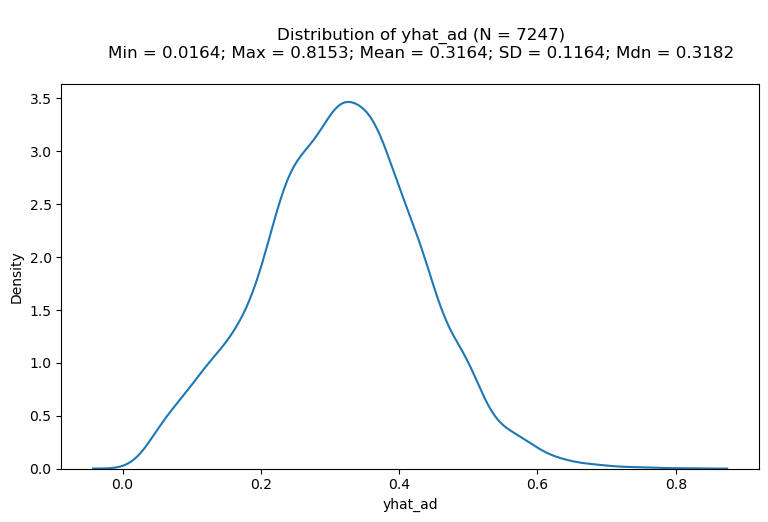

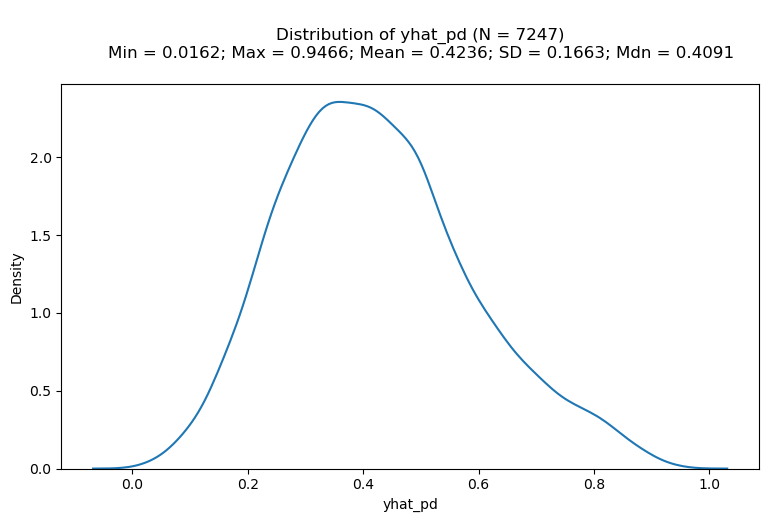

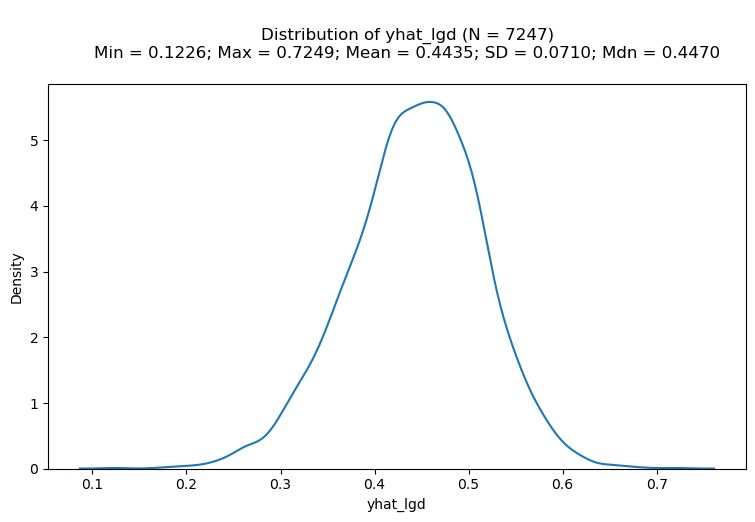

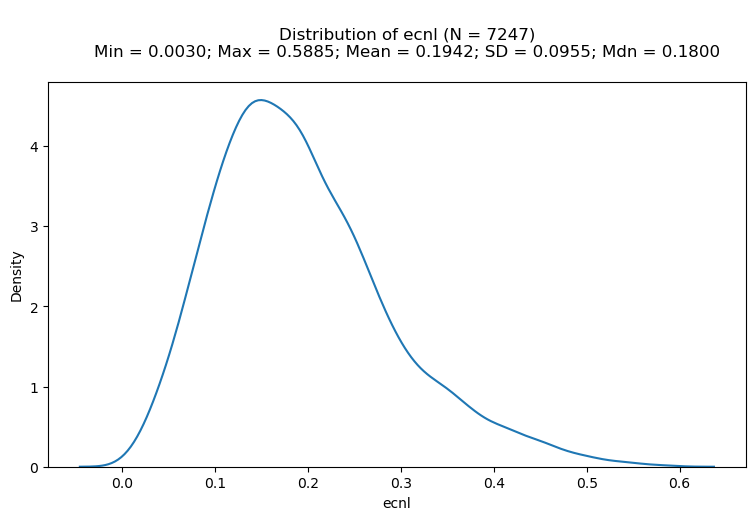

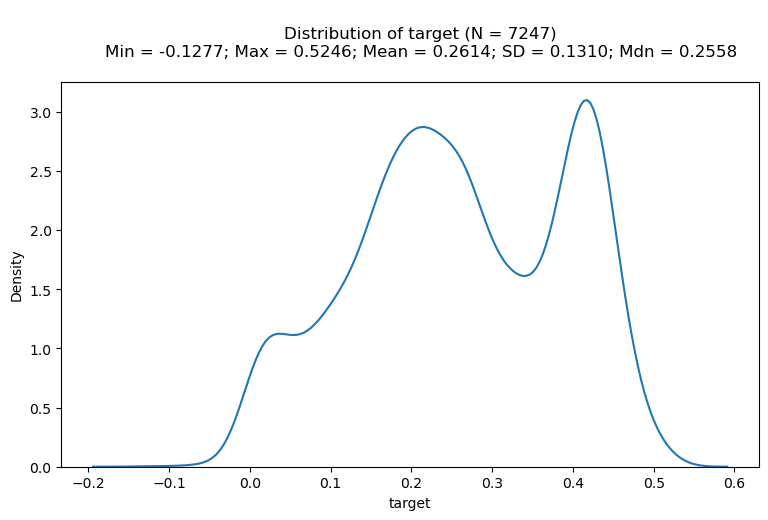

In [22]:
list_str_col = [
    'yhat_ad',
    'yhat_pd',
    'yhat_lgd',
    'ecnl',
    'target',
]
for str_col in list_str_col:
    show_distribution(
        df=df, 
        str_col=str_col,
    )

### Visualize relationships between predictions and target at the account level

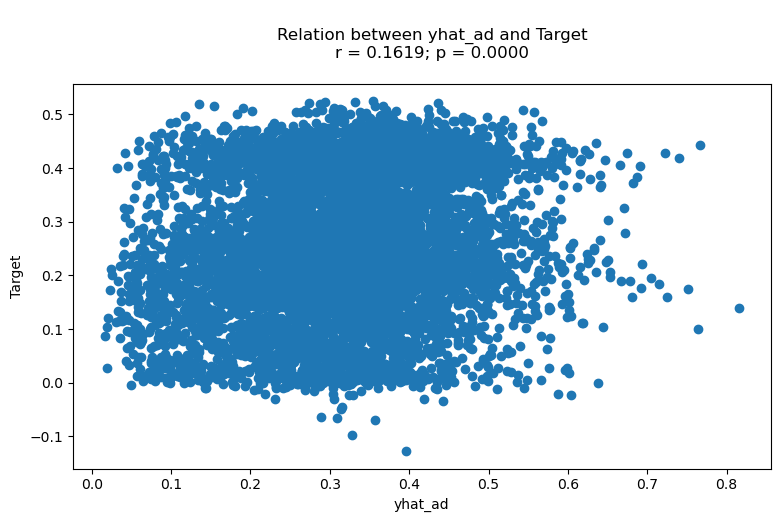

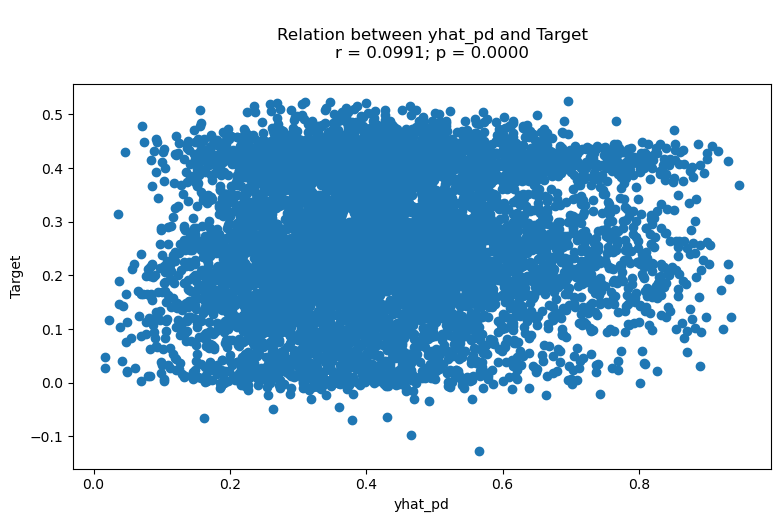

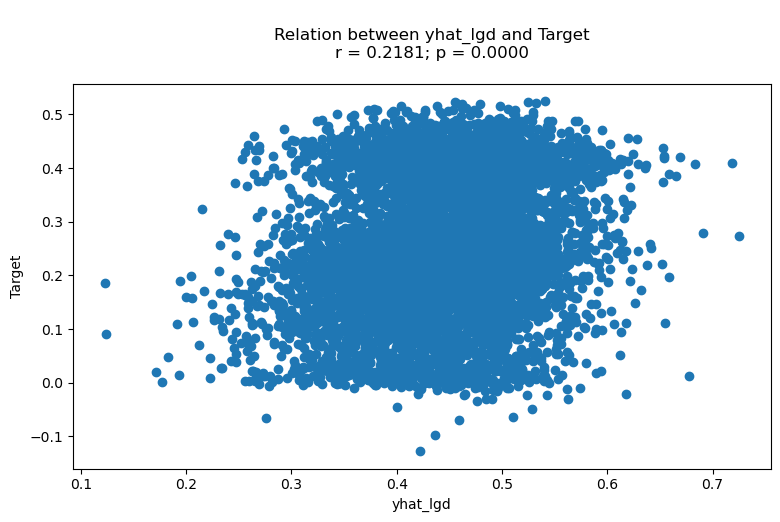

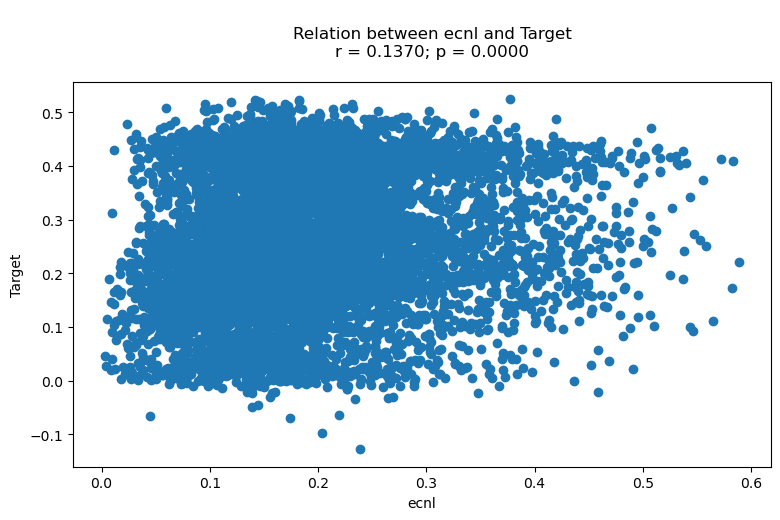

In [23]:
list_str_x = [
    'yhat_ad',
    'yhat_pd',
    'yhat_lgd',
    'ecnl',
]
for str_x in list_str_x:
    visualize_relation(
        df=df, 
        str_x=str_x,
    )

### Evaluate loss using LGD model and an LGD constant

In [24]:
flt_mean_loss = df['target'].mean()
print(f'Mean actual loss: {flt_mean_loss:0.4f}')
flt_mean_ecnl_w_lgd = df['ecnl'].mean()
print(f'Mean ECNL using LGD model: {flt_mean_ecnl_w_lgd:0.4f}')
flt_mean_pd = df['yhat_pd'].mean()
print(f'Mean PD: {flt_mean_pd:0.4f}')
# solve for LGD
flt_lgd_constant = flt_mean_loss / flt_mean_pd
print(f'LGD Constant: {flt_lgd_constant:0.4f}')
df['lgd_constant'] = flt_lgd_constant
df['ecnl_w_constant'] = df['yhat_pd'] * df['lgd_constant']
flt_mean_ecnl_w_constant = df['ecnl_w_constant'].mean()
print(f'Mean ECNL using LGD constant: {flt_mean_ecnl_w_constant:0.4f}')
df

Mean actual loss: 0.2614
Mean ECNL using LGD model: 0.1942
Mean PD: 0.4236
LGD Constant: 0.6170
Mean ECNL using LGD constant: 0.2614


,application_month,funded_month,intopenbktype__app,amtfinanced__app,yhat_ad,yhat_pd,yhat_lgd,data_set,ecnl,dtmBooking,BookingQuarter,target,MonthEndDate,str_month_end,booking_month,months_on_books,lgd_constant,ecnl_w_constant
0,2017-06-01,2017-09-01,nan,14500.0,0.483449,0.567174,0.530013,train,0.300610,2017-09-14 14:18:55.000,2017 Q3,0.249186,2019-08-31,2019-08-31,2017-09-01 14:18:55.000,24,0.617044,0.349972
1,2017-07-01,2017-09-01,13.0,16500.0,0.151613,0.483340,0.433228,train,0.209396,2017-09-21 14:24:57.000,2017 Q3,0.227433,2019-08-31,2019-08-31,2017-09-01 14:24:57.000,24,0.617044,0.298242
2,2017-07-01,2017-09-01,13.0,20000.0,0.142818,0.313088,0.275318,train,0.086199,2017-09-13 16:39:30.000,2017 Q3,0.100427,2019-08-31,2019-08-31,2017-09-01 16:39:30.000,24,0.617044,0.193189
3,2017-07-01,2017-09-01,13.0,16000.0,0.215636,0.230918,0.293667,train,0.067813,2017-09-13 14:05:58.000,2017 Q3,0.089602,2019-08-31,2019-08-31,2017-09-01 14:05:58.000,24,0.617044,0.142486
4,2017-07-01,2017-09-01,13.0,20000.0,0.054314,0.054619,0.265412,train,0.014497,2017-09-26 12:50:59.000,2017 Q3,0.083615,2019-08-31,2019-08-31,2017-09-01 12:50:59.000,24,0.617044,0.033702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7387,2022-02-01,2022-02-01,nan,20500.0,0.391801,0.229290,0.553119,prod,0.126825,2022-02-28 14:39:46.467,2022 Q1,0.378948,2024-01-31,2024-01-31,2022-02-01 14:39:46.467,24,0.617044,0.141482
7395,2022-02-01,2022-02-01,nan,19000.0,0.440659,0.755520,0.473955,prod,0.358082,2022-02-25 16:05:29.773,2022 Q1,0.313396,2024-01-31,2024-01-31,2022-02-01 16:05:29.773,24,0.617044,0.466189
7396,2022-02-01,2022-02-01,nan,18000.0,0.445631,0.491412,0.519017,prod,0.255052,2022-02-25 13:19:31.077,2022 Q1,0.240651,2024-01-31,2024-01-31,2022-02-01 13:19:31.077,24,0.617044,0.303223
7406,2022-02-01,2022-02-01,nan,25000.0,0.477159,0.434089,0.412508,prod,0.179065,2022-02-25 16:34:27.513,2022 Q1,0.250582,2024-01-31,2024-01-31,2022-02-01 16:34:27.513,24,0.617044,0.267852


## POC forecasting

### Examine trends over time

In [25]:
# plot averages over time
df['count'] = 1
df_grouped = df.groupby(by='application_month', as_index=False).agg({
    'yhat_ad': 'mean',
    'yhat_pd': 'mean',
    'yhat_lgd': 'mean',
    'ecnl': 'mean',
    'target': 'mean',
    'data_set': 'first',
    'count': 'sum',
})
df_grouped

,application_month,yhat_ad,yhat_pd,yhat_lgd,ecnl,target,data_set,count
0,2017-06-01,0.483449,0.567174,0.530013,0.300610,0.249186,train,1
1,2017-07-01,0.215870,0.370352,0.369850,0.165127,0.178068,train,5
2,2017-08-01,0.330442,0.468211,0.449782,0.218199,0.233492,train,52
3,2017-09-01,0.321677,0.452073,0.444630,0.213487,0.243065,train,95
4,2017-10-01,0.337853,0.460981,0.446417,0.213184,0.253622,train,67
5,2017-11-01,0.295043,0.455841,0.430287,0.209756,0.210708,train,95
6,2017-12-01,0.324266,0.496465,0.452960,0.234418,0.249981,train,91
7,2018-01-01,0.322205,0.478990,0.438534,0.220484,0.217741,train,95
8,2018-02-01,0.319692,0.401687,0.418653,0.174873,0.253394,train,63
9,2018-03-01,0.333527,0.454531,0.447891,0.210943,0.249657,train,74


### Visualize relationships between predictions and target at the vintage level

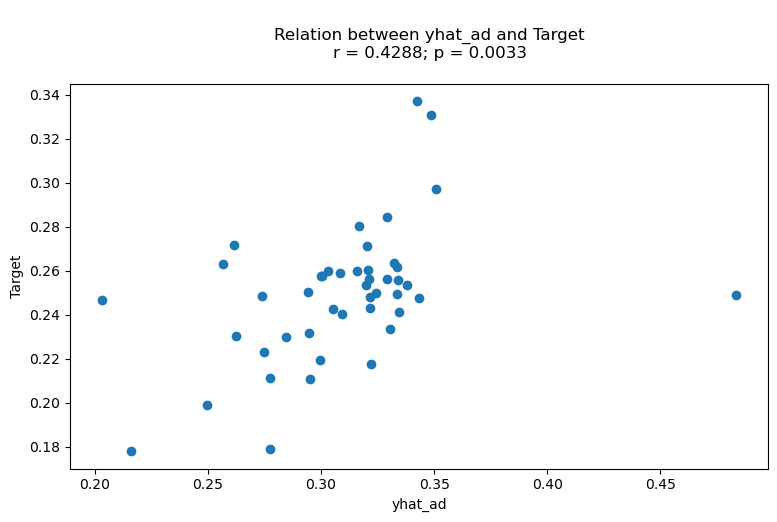

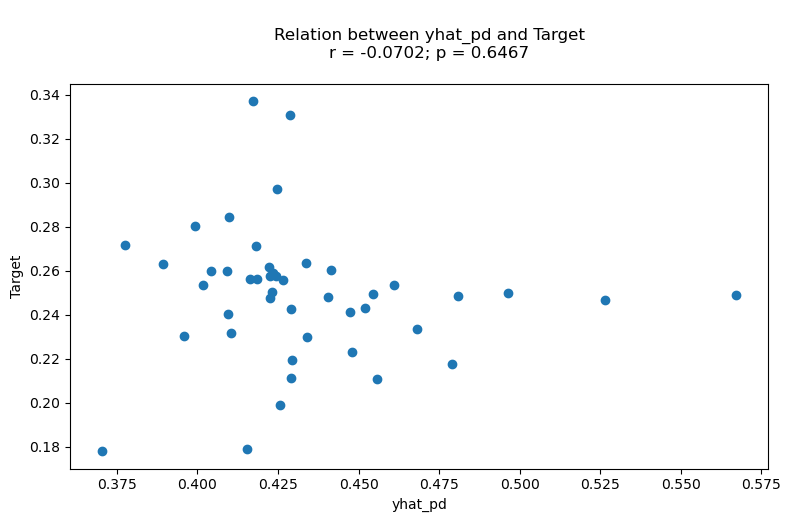

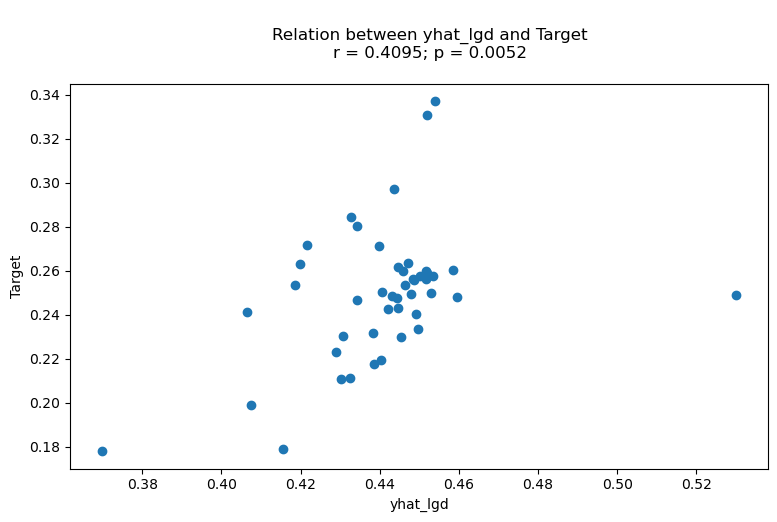

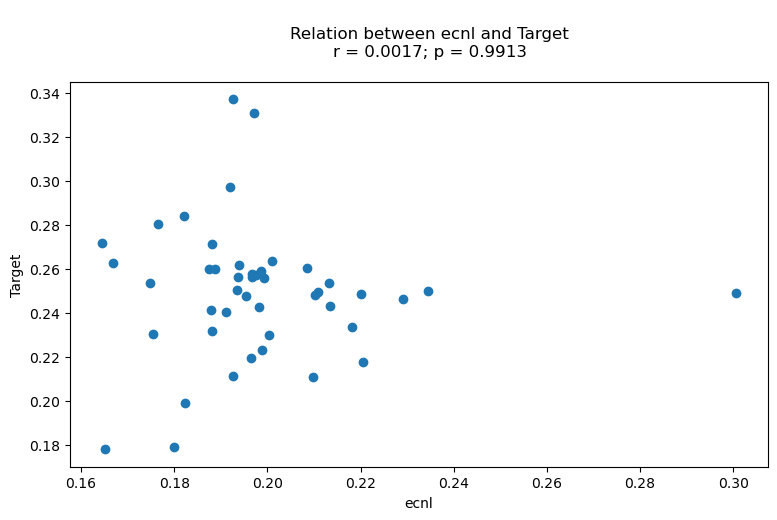

In [26]:
list_str_x = [
    'yhat_ad',
    'yhat_pd',
    'yhat_lgd',
    'ecnl',
]
for str_x in list_str_x:
    visualize_relation(
        df=df_grouped, 
        str_x=str_x,
    )

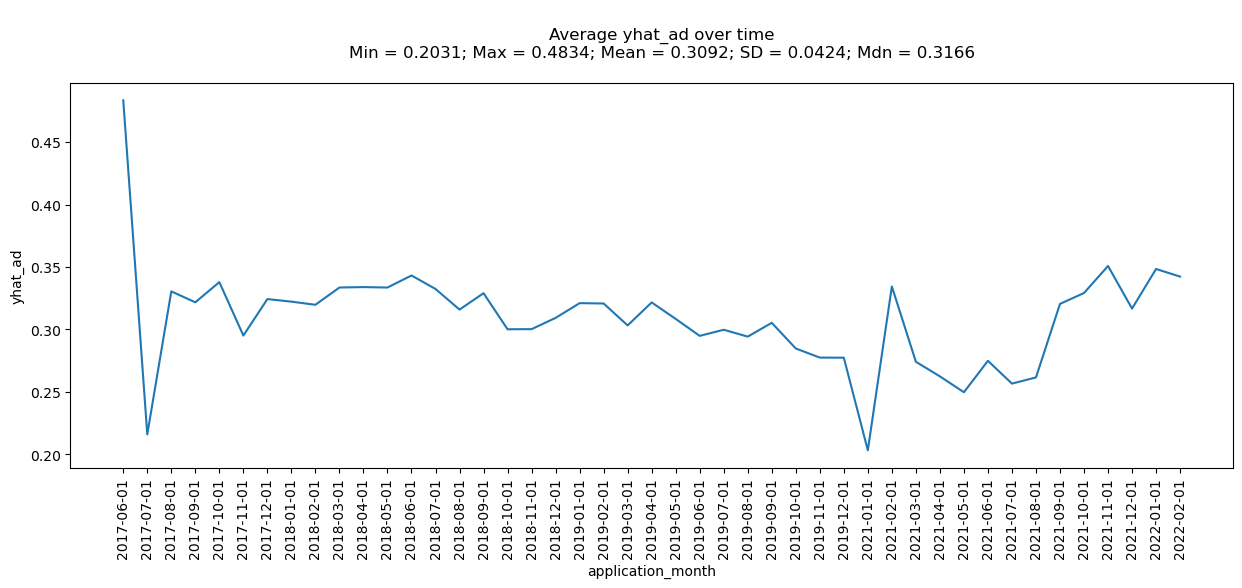

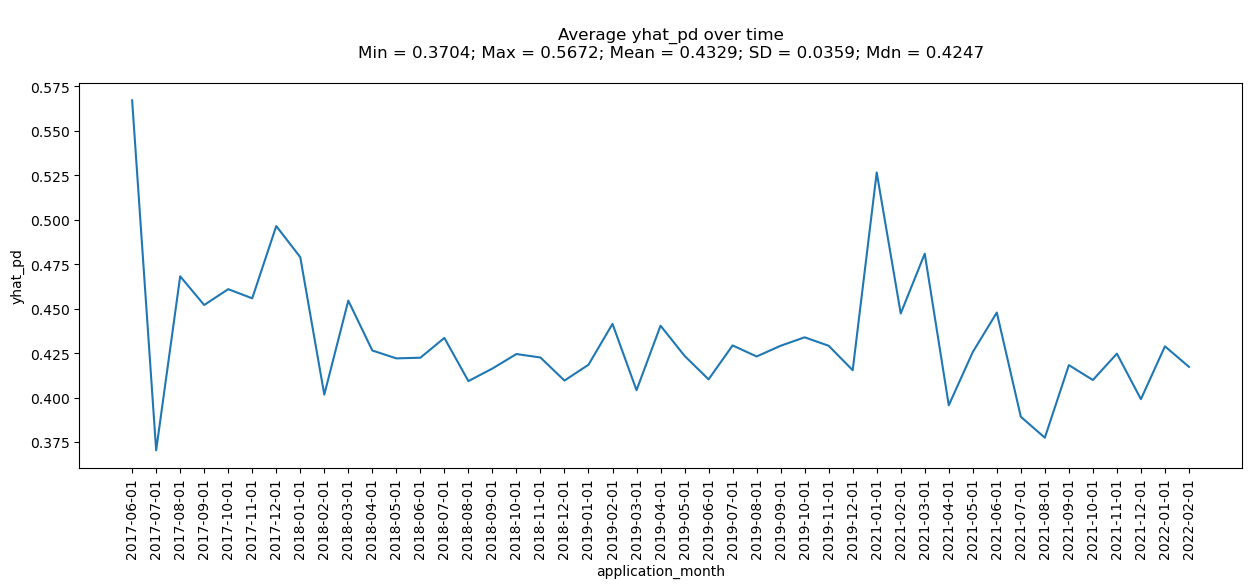

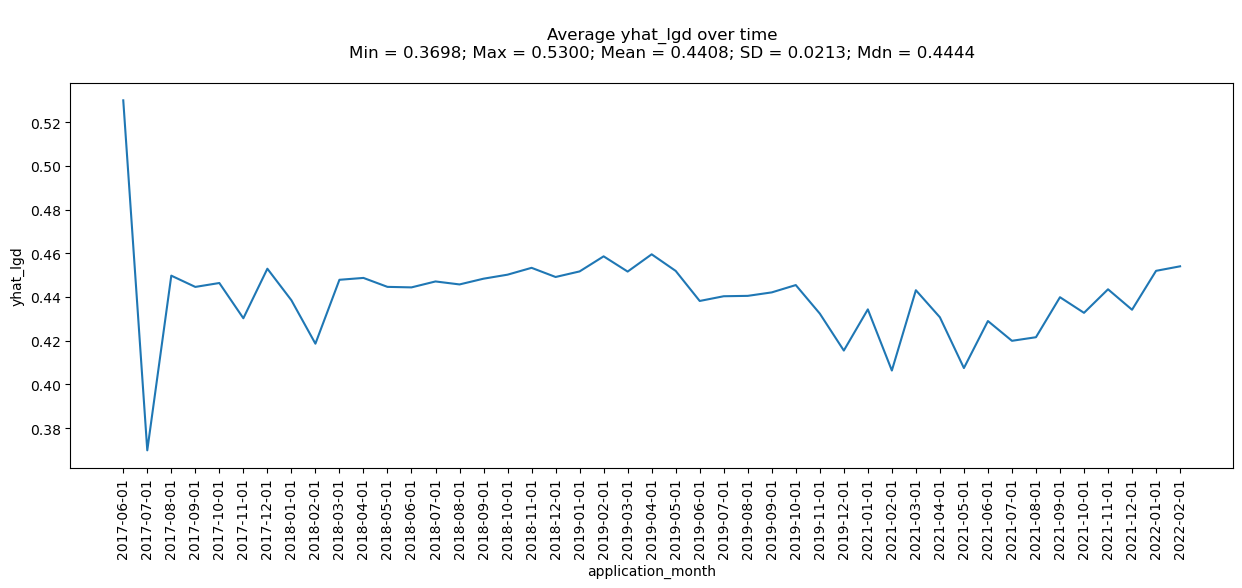

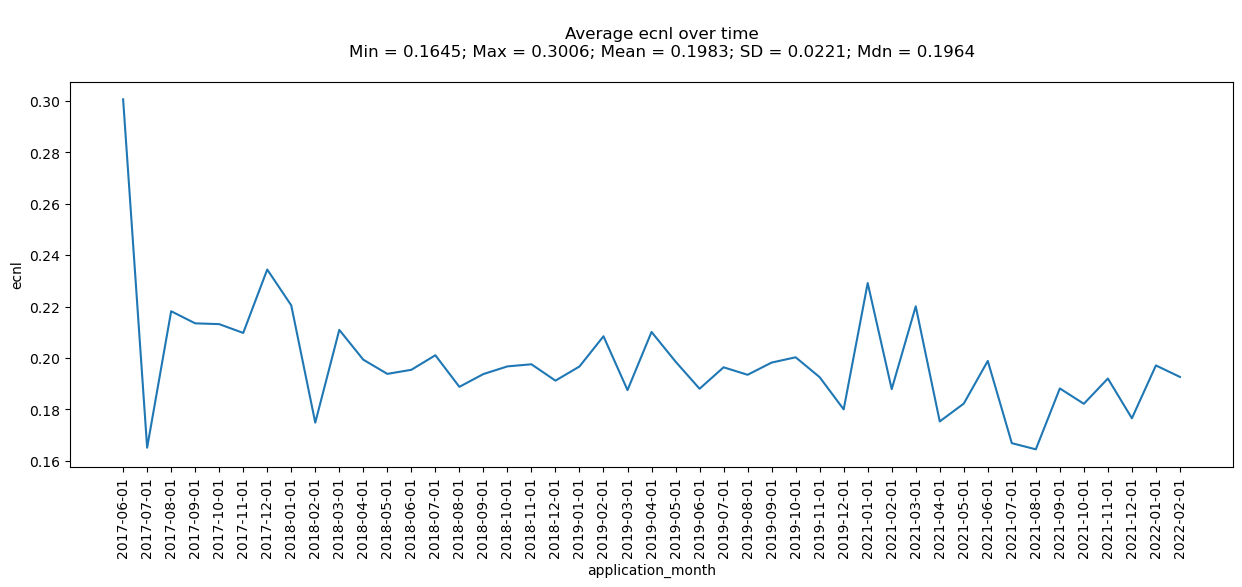

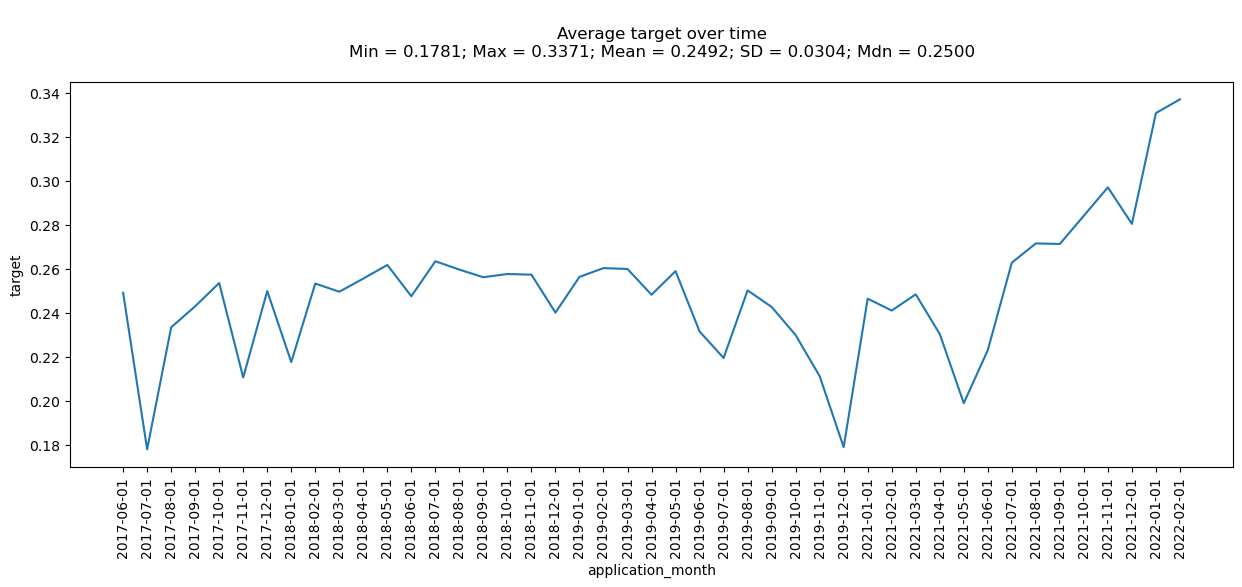

In [27]:
list_str_col = [
    'yhat_ad',
    'yhat_pd',
    'yhat_lgd',
    'ecnl',
    'target',
]
for str_col in list_str_col:
    plot_over_time(
        df=df_grouped, 
        str_col=str_col,
    )

### Plot all on same graph

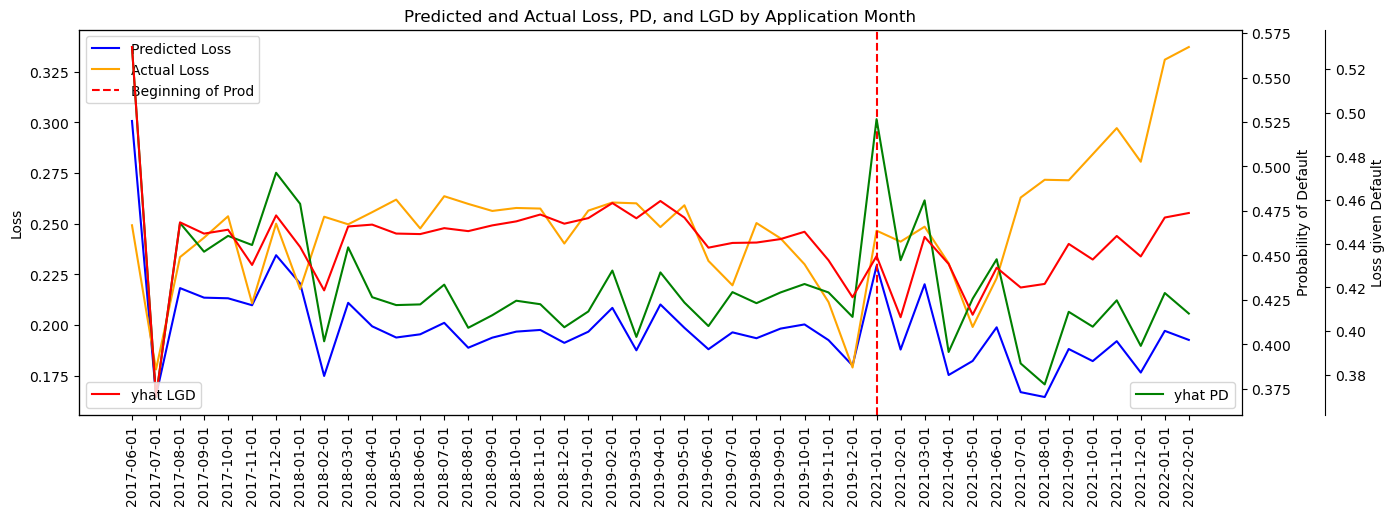

In [28]:
# get month where prod starts
dtm_app_month_prod = df_grouped[df_grouped['data_set'] == 'prod'].copy()['application_month'].iloc[0]
# plot
fig, ax = plt.subplots(figsize=(15,5))
ax.set_title('Predicted and Actual Loss, PD, and LGD by Application Month')
# loss
ax.set_ylabel('Loss')
ax.plot(df_grouped['application_month'], df_grouped['ecnl'], color='blue', label='Predicted Loss')
ax.plot(df_grouped['application_month'], df_grouped['target'], color='orange', label='Actual Loss')
ax.axvline(dtm_app_month_prod, linestyle='--', color='red', label='Beginning of Prod')
ax.set_xticklabels(df_grouped['application_month'], rotation=90)
plt.legend(loc='upper left')
# pd
ax2 = ax.twinx()
ax2.set_ylabel('Probability of Default')
ax2.plot(df_grouped['application_month'], df_grouped['yhat_pd'], color='green', label='yhat PD')
plt.legend(loc='lower right')
# lgd
ax3 = ax.twinx()
ax3.set_ylabel('Loss given Default')
ax3.plot(df_grouped['application_month'], df_grouped['yhat_lgd'], color='red', label='yhat LGD')
plt.legend(loc='lower left')

# offset the third y-axis
ax3.spines['right'].set_position(('outward', 60))

# show
plt.show()

### Plot just the predicted and actual loss on the same graph

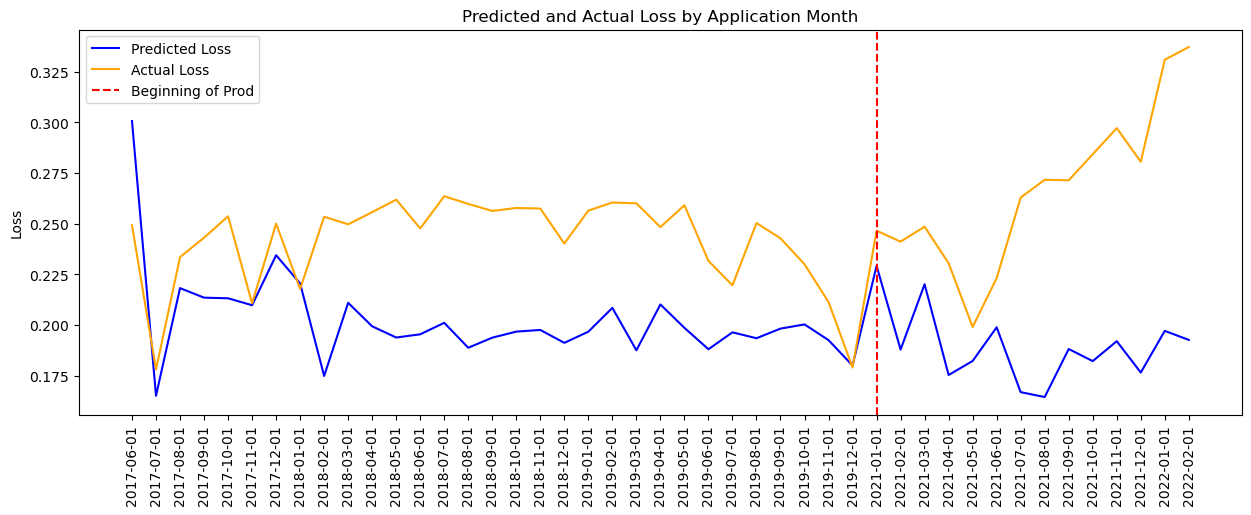

In [29]:
# get month where prod starts
dtm_app_month_prod = df_grouped[df_grouped['data_set'] == 'prod'].copy()['application_month'].iloc[0]
# plot
fig, ax = plt.subplots(figsize=(15,5))
ax.set_title('Predicted and Actual Loss by Application Month')
# loss
ax.set_ylabel('Loss')
ax.plot(df_grouped['application_month'], df_grouped['ecnl'], color='blue', label='Predicted Loss')
ax.plot(df_grouped['application_month'], df_grouped['target'], color='orange', label='Actual Loss')
ax.axvline(dtm_app_month_prod, linestyle='--', color='red', label='Beginning of Prod')
ax.set_xticklabels(df_grouped['application_month'], rotation=90)
plt.legend(loc='upper left')

# show
plt.show()

### Subset to prod only

In [30]:
df_grouped = df_grouped[df_grouped['data_set'] == 'prod'].copy()
df_grouped

,application_month,yhat_ad,yhat_pd,yhat_lgd,ecnl,target,data_set,count
31,2021-01-01,0.203118,0.526596,0.434354,0.229152,0.246523,prod,2
32,2021-02-01,0.334379,0.447304,0.406370,0.187895,0.241112,prod,11
33,2021-03-01,0.274048,0.480940,0.443116,0.220104,0.248485,prod,17
34,2021-04-01,0.262352,0.395687,0.430739,0.175336,0.230464,prod,20
35,2021-05-01,0.249654,0.425629,0.407500,0.182271,0.199039,prod,31
36,2021-06-01,0.274819,0.447831,0.429023,0.198869,0.223125,prod,80
37,2021-07-01,0.256567,0.389223,0.419966,0.166888,0.262864,prod,111
38,2021-08-01,0.261514,0.377455,0.421608,0.164487,0.271619,prod,135
39,2021-09-01,0.320394,0.418271,0.439915,0.188167,0.271373,prod,393
40,2021-10-01,0.329138,0.409905,0.432770,0.182201,0.284218,prod,428


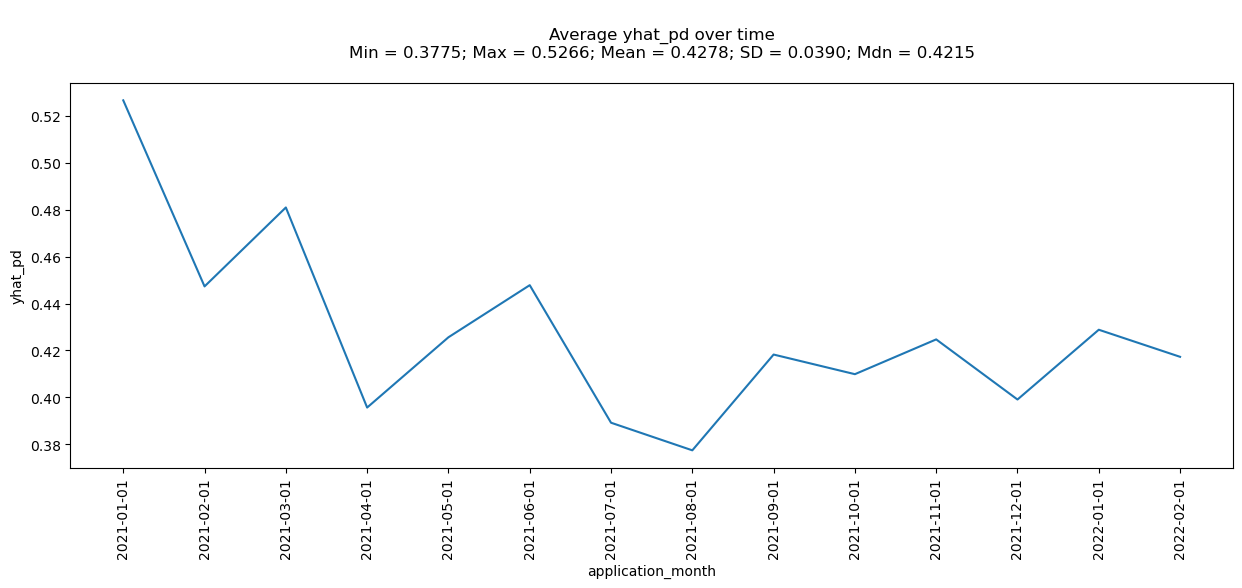

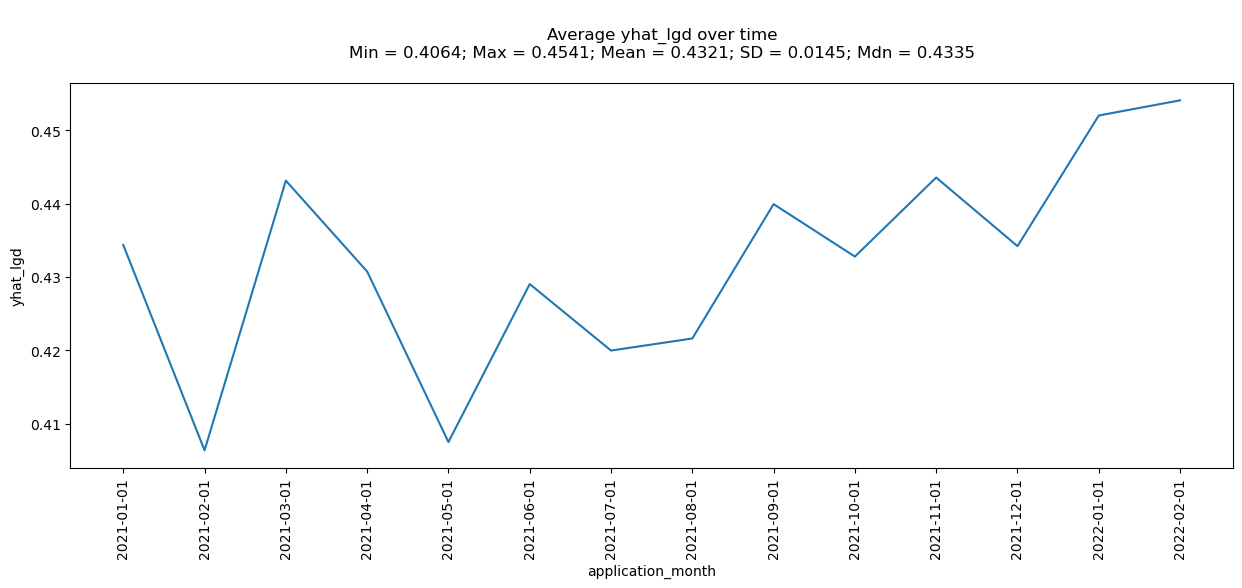

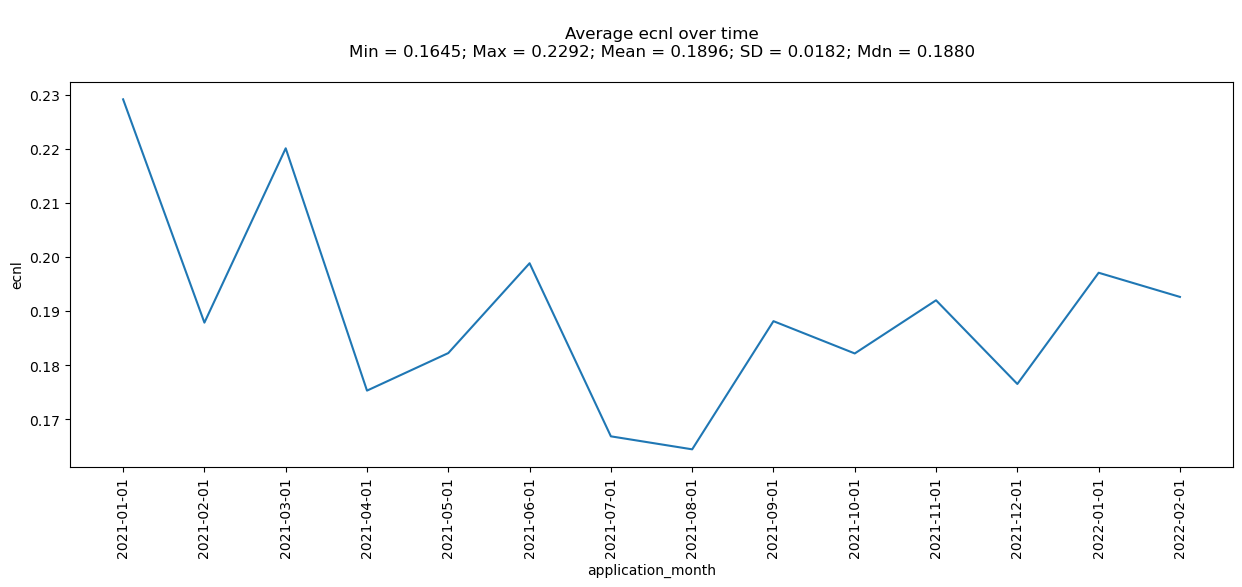

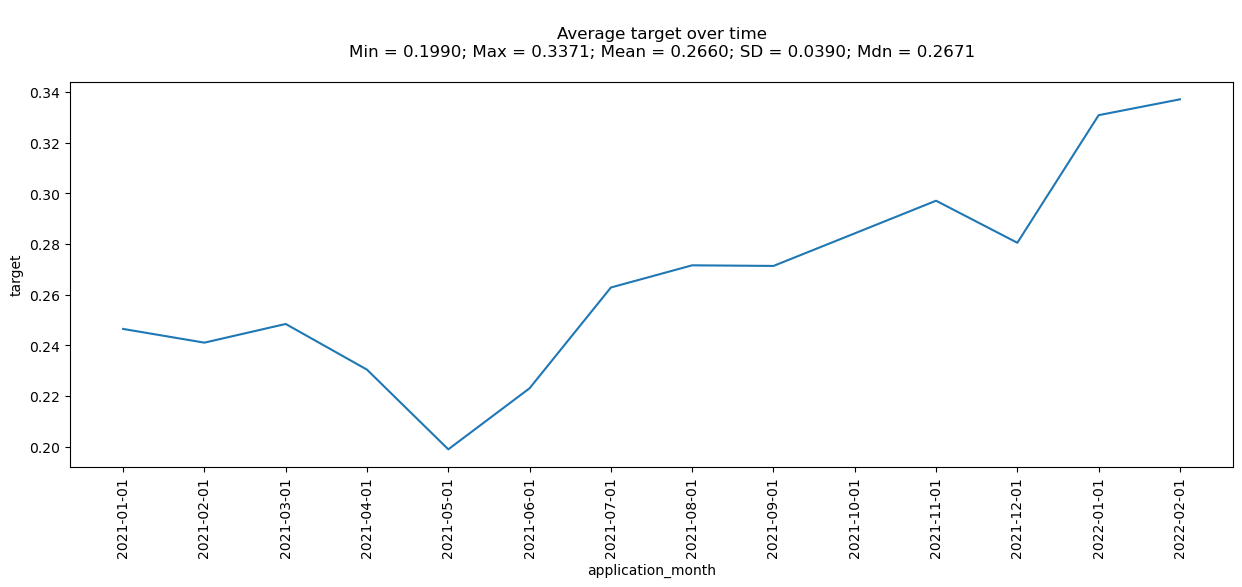

In [31]:
list_str_col = [
    'yhat_pd',
    'yhat_lgd',
    'ecnl',
    'target',
]
for str_col in list_str_col:
    plot_over_time(
        df=df_grouped, 
        str_col=str_col,
    )

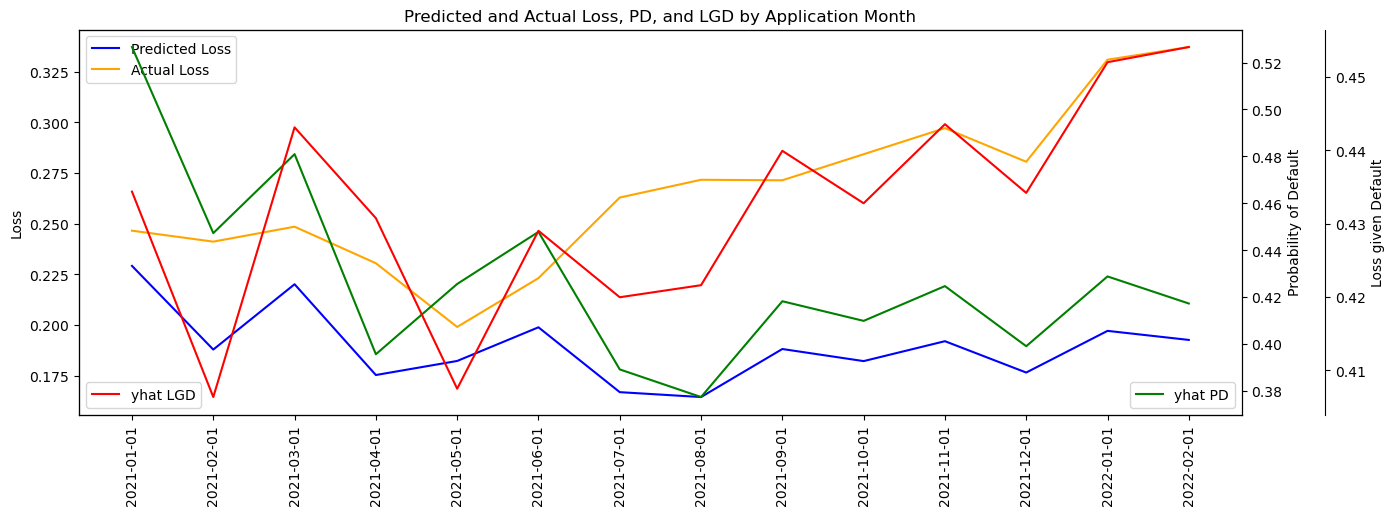

In [32]:
# plot
fig, ax = plt.subplots(figsize=(15,5))
ax.set_title('Predicted and Actual Loss, PD, and LGD by Application Month')
# loss
ax.set_ylabel('Loss')
ax.plot(df_grouped['application_month'], df_grouped['ecnl'], color='blue', label='Predicted Loss')
ax.plot(df_grouped['application_month'], df_grouped['target'], color='orange', label='Actual Loss')
ax.set_xticklabels(df_grouped['application_month'], rotation=90)
plt.legend(loc='upper left')
# pd
ax2 = ax.twinx()
ax2.set_ylabel('Probability of Default')
ax2.plot(df_grouped['application_month'], df_grouped['yhat_pd'], color='green', label='yhat PD')
plt.legend(loc='lower right')
# lgd
ax3 = ax.twinx()
ax3.set_ylabel('Loss given Default')
ax3.plot(df_grouped['application_month'], df_grouped['yhat_lgd'], color='red', label='yhat LGD')
plt.legend(loc='lower left')

# offset the third y-axis
ax3.spines['right'].set_position(('outward', 60))

# show
plt.show()

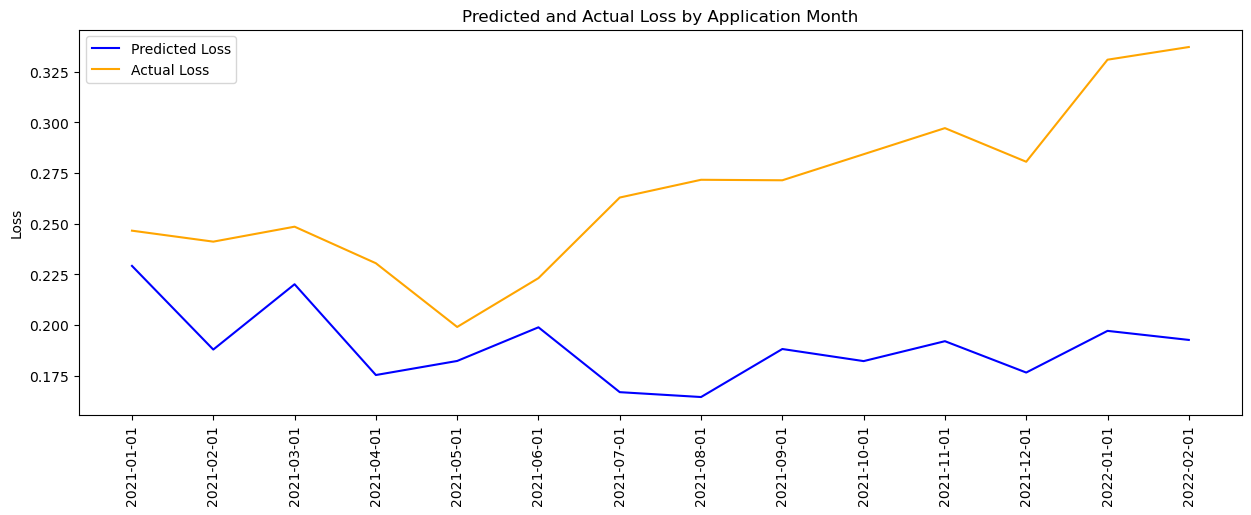

In [33]:
# plot
fig, ax = plt.subplots(figsize=(15,5))
ax.set_title('Predicted and Actual Loss by Application Month')
# loss
ax.set_ylabel('Loss')
ax.plot(df_grouped['application_month'], df_grouped['ecnl'], color='blue', label='Predicted Loss')
ax.plot(df_grouped['application_month'], df_grouped['target'], color='orange', label='Actual Loss')
ax.set_xticklabels(df_grouped['application_month'], rotation=90)
plt.legend(loc='upper left')

# show
plt.show()

### Train, test split

In [34]:
# train, test split
df_grouped = train_test_split(
    df=df_grouped,
    flt_prop_train=0.75,
)
df_grouped['month_number'] = list(range(1, df_grouped.shape[0]+1))
df_grouped

,application_month,yhat_ad,yhat_pd,yhat_lgd,ecnl,target,data_set,count,month_number
31,2021-01-01,0.203118,0.526596,0.434354,0.229152,0.246523,Train,2,1
32,2021-02-01,0.334379,0.447304,0.406370,0.187895,0.241112,Train,11,2
33,2021-03-01,0.274048,0.480940,0.443116,0.220104,0.248485,Train,17,3
34,2021-04-01,0.262352,0.395687,0.430739,0.175336,0.230464,Train,20,4
35,2021-05-01,0.249654,0.425629,0.407500,0.182271,0.199039,Train,31,5
36,2021-06-01,0.274819,0.447831,0.429023,0.198869,0.223125,Train,80,6
37,2021-07-01,0.256567,0.389223,0.419966,0.166888,0.262864,Train,111,7
38,2021-08-01,0.261514,0.377455,0.421608,0.164487,0.271619,Train,135,8
39,2021-09-01,0.320394,0.418271,0.439915,0.188167,0.271373,Train,393,9
40,2021-10-01,0.329138,0.409905,0.432770,0.182201,0.284218,Train,428,10


### Forecast the actual loss because we will need it to get a forecasted LGD constant

In [35]:
# fit simple linear regression model to forecast actual loss
cls_model = LinearRegression()
list_cols = [
    'month_number'
]
X = df_grouped[df_grouped['data_set'] == 'Train'].copy()[list_cols]
y = df_grouped[df_grouped['data_set'] == 'Train'].copy()['target']
cls_model.fit(X, y)
# predict
X_tmp = df_grouped[df_grouped['data_set'] == 'Test'].copy()[list_cols]
X_tmp['yhat_loss'] = list(cls_model.predict(X_tmp))
X_tmp['yhat_loss'] = X_tmp['yhat_loss'] + flt_loss_buffer
# join
df_grouped = pd.merge(
    left=df_grouped,
    right=X_tmp,
    on='month_number',
    how='left',
)
df_grouped

,application_month,yhat_ad,yhat_pd,yhat_lgd,ecnl,target,data_set,count,month_number,yhat_loss
0,2021-01-01,0.203118,0.526596,0.434354,0.229152,0.246523,Train,2,1,NaN
1,2021-02-01,0.334379,0.447304,0.406370,0.187895,0.241112,Train,11,2,NaN
2,2021-03-01,0.274048,0.480940,0.443116,0.220104,0.248485,Train,17,3,NaN
3,2021-04-01,0.262352,0.395687,0.430739,0.175336,0.230464,Train,20,4,NaN
4,2021-05-01,0.249654,0.425629,0.407500,0.182271,0.199039,Train,31,5,NaN
5,2021-06-01,0.274819,0.447831,0.429023,0.198869,0.223125,Train,80,6,NaN
6,2021-07-01,0.256567,0.389223,0.419966,0.166888,0.262864,Train,111,7,NaN
7,2021-08-01,0.261514,0.377455,0.421608,0.164487,0.271619,Train,135,8,NaN
8,2021-09-01,0.320394,0.418271,0.439915,0.188167,0.271373,Train,393,9,NaN
9,2021-10-01,0.329138,0.409905,0.432770,0.182201,0.284218,Train,428,10,NaN


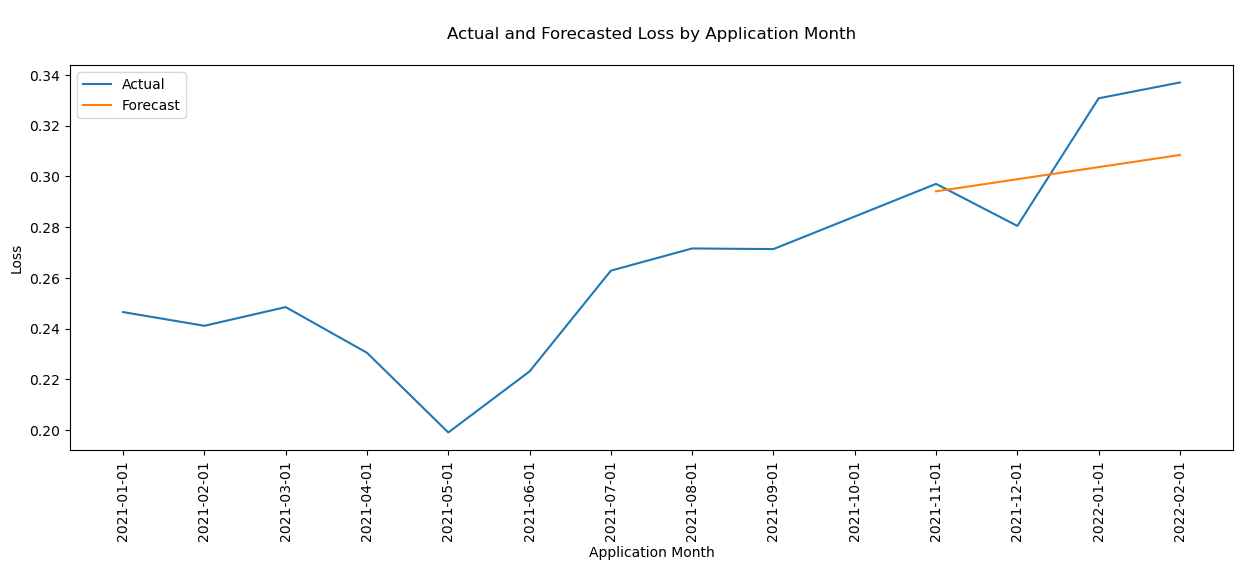

In [36]:
# plot
str_title = f"""
Actual and Forecasted Loss by Application Month
"""
fig, ax = plt.subplots(figsize=(15,5))
ax.set_title(str_title)
ax.set_xlabel('Application Month')
ax.set_ylabel('Loss')
ax.plot(df_grouped['application_month'], df_grouped['target'], label='Actual')
ax.plot(df_grouped['application_month'], df_grouped['yhat_loss'], label='Forecast')
ax.set_xticklabels(df_grouped['application_month'], rotation=90)
plt.legend()
plt.show()

### Forecast the PD score from the model because we will need it to get a forecasted LGD constant

In [37]:
# fit simple linear regression model to forecast pd
cls_model = LinearRegression()
list_cols = [
    'month_number'
]
X = df_grouped[df_grouped['data_set'] == 'Train'].copy()[list_cols]
y = df_grouped[df_grouped['data_set'] == 'Train'].copy()['yhat_pd']
cls_model.fit(X, y)
# predict
X_tmp = df_grouped[df_grouped['data_set'] == 'Test'].copy()[list_cols]
X_tmp['yhat_yhat_pd'] = list(cls_model.predict(X_tmp))
X_tmp['yhat_yhat_pd'] = X_tmp['yhat_yhat_pd'] + flt_pd_buffer
# join
df_grouped = pd.merge(
    left=df_grouped,
    right=X_tmp,
    on='month_number',
    how='left',
)
df_grouped

,application_month,yhat_ad,yhat_pd,yhat_lgd,ecnl,target,data_set,count,month_number,yhat_loss,yhat_yhat_pd
0,2021-01-01,0.203118,0.526596,0.434354,0.229152,0.246523,Train,2,1,NaN,NaN
1,2021-02-01,0.334379,0.447304,0.406370,0.187895,0.241112,Train,11,2,NaN,NaN
2,2021-03-01,0.274048,0.480940,0.443116,0.220104,0.248485,Train,17,3,NaN,NaN
3,2021-04-01,0.262352,0.395687,0.430739,0.175336,0.230464,Train,20,4,NaN,NaN
4,2021-05-01,0.249654,0.425629,0.407500,0.182271,0.199039,Train,31,5,NaN,NaN
5,2021-06-01,0.274819,0.447831,0.429023,0.198869,0.223125,Train,80,6,NaN,NaN
6,2021-07-01,0.256567,0.389223,0.419966,0.166888,0.262864,Train,111,7,NaN,NaN
7,2021-08-01,0.261514,0.377455,0.421608,0.164487,0.271619,Train,135,8,NaN,NaN
8,2021-09-01,0.320394,0.418271,0.439915,0.188167,0.271373,Train,393,9,NaN,NaN
9,2021-10-01,0.329138,0.409905,0.432770,0.182201,0.284218,Train,428,10,NaN,NaN


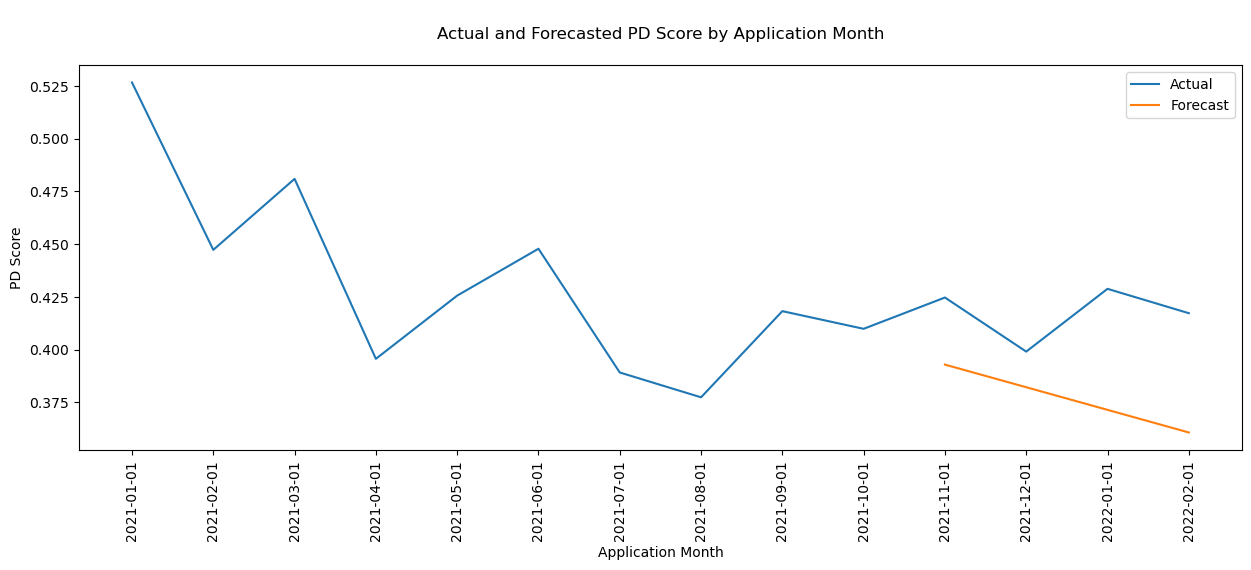

In [38]:
# plot
str_title = f"""
Actual and Forecasted PD Score by Application Month
"""
fig, ax = plt.subplots(figsize=(15,5))
ax.set_title(str_title)
ax.set_xlabel('Application Month')
ax.set_ylabel('PD Score')
ax.plot(df_grouped['application_month'], df_grouped['yhat_pd'], label='Actual')
ax.plot(df_grouped['application_month'], df_grouped['yhat_yhat_pd'], label='Forecast')
ax.set_xticklabels(df_grouped['application_month'], rotation=90)
plt.legend()
plt.show()

### Get the forecasted LGD constant using forecasted loss and forecasted PD score

In [39]:
# get the lgd constant (actual)
df_grouped['lgd_constant'] = df_grouped['target'] / df_grouped['yhat_pd']
# get forecasted lgd constant
df_grouped['yhat_lgd_constant'] = df_grouped['yhat_loss'] / df_grouped['yhat_yhat_pd']
# show
df_grouped

,application_month,yhat_ad,yhat_pd,yhat_lgd,ecnl,target,data_set,count,month_number,yhat_loss,yhat_yhat_pd,lgd_constant,yhat_lgd_constant
0,2021-01-01,0.203118,0.526596,0.434354,0.229152,0.246523,Train,2,1,NaN,NaN,0.468144,NaN
1,2021-02-01,0.334379,0.447304,0.406370,0.187895,0.241112,Train,11,2,NaN,NaN,0.539034,NaN
2,2021-03-01,0.274048,0.480940,0.443116,0.220104,0.248485,Train,17,3,NaN,NaN,0.516665,NaN
3,2021-04-01,0.262352,0.395687,0.430739,0.175336,0.230464,Train,20,4,NaN,NaN,0.582440,NaN
4,2021-05-01,0.249654,0.425629,0.407500,0.182271,0.199039,Train,31,5,NaN,NaN,0.467636,NaN
5,2021-06-01,0.274819,0.447831,0.429023,0.198869,0.223125,Train,80,6,NaN,NaN,0.498235,NaN
6,2021-07-01,0.256567,0.389223,0.419966,0.166888,0.262864,Train,111,7,NaN,NaN,0.675357,NaN
7,2021-08-01,0.261514,0.377455,0.421608,0.164487,0.271619,Train,135,8,NaN,NaN,0.719605,NaN
8,2021-09-01,0.320394,0.418271,0.439915,0.188167,0.271373,Train,393,9,NaN,NaN,0.648798,NaN
9,2021-10-01,0.329138,0.409905,0.432770,0.182201,0.284218,Train,428,10,NaN,NaN,0.693374,NaN


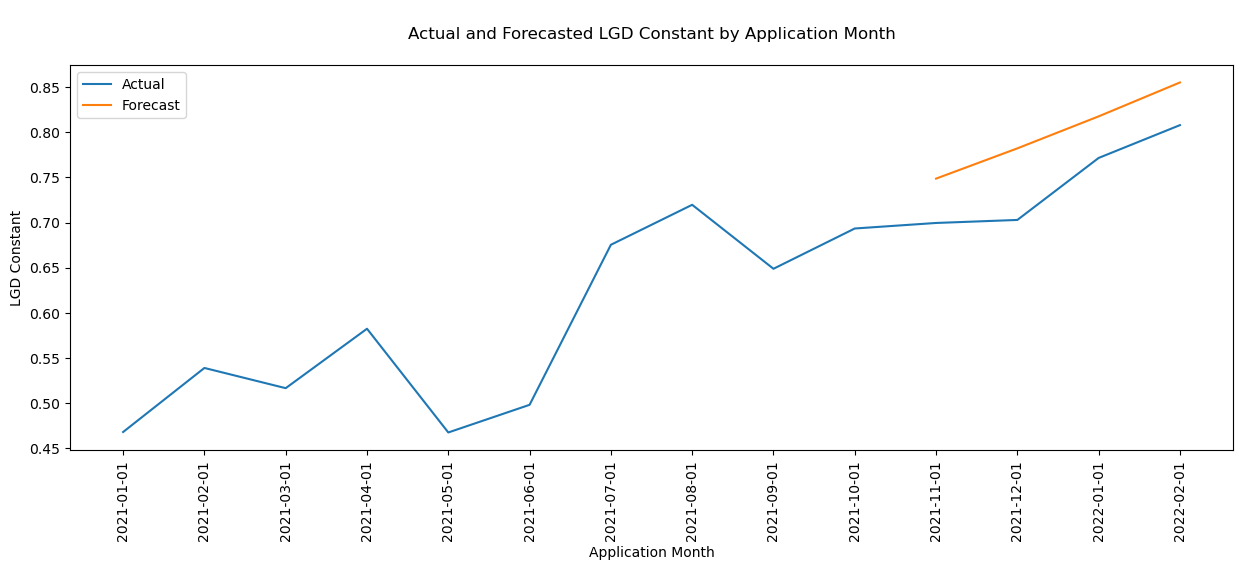

In [40]:
# plot
str_title = f"""
Actual and Forecasted LGD Constant by Application Month
"""
fig, ax = plt.subplots(figsize=(15,5))
ax.set_title(str_title)
ax.set_xlabel('Application Month')
ax.set_ylabel('LGD Constant')
ax.plot(df_grouped['application_month'], df_grouped['lgd_constant'], label='Actual')
ax.plot(df_grouped['application_month'], df_grouped['yhat_lgd_constant'], label='Forecast')
ax.set_xticklabels(df_grouped['application_month'], rotation=90)
plt.legend()
plt.show()

### Get the forecasted loss for pricing using the forecasted PD score and forecasted LGD constant

In [41]:
# get the predicted loss using the forecasted pd and forecasted lgd constant
df_grouped['forecasted_pricing'] = df_grouped['yhat_yhat_pd'] * df_grouped['yhat_lgd_constant']
# show
df_grouped

,application_month,yhat_ad,yhat_pd,yhat_lgd,ecnl,target,data_set,count,month_number,yhat_loss,yhat_yhat_pd,lgd_constant,yhat_lgd_constant,forecasted_pricing
0,2021-01-01,0.203118,0.526596,0.434354,0.229152,0.246523,Train,2,1,NaN,NaN,0.468144,NaN,NaN
1,2021-02-01,0.334379,0.447304,0.406370,0.187895,0.241112,Train,11,2,NaN,NaN,0.539034,NaN,NaN
2,2021-03-01,0.274048,0.480940,0.443116,0.220104,0.248485,Train,17,3,NaN,NaN,0.516665,NaN,NaN
3,2021-04-01,0.262352,0.395687,0.430739,0.175336,0.230464,Train,20,4,NaN,NaN,0.582440,NaN,NaN
4,2021-05-01,0.249654,0.425629,0.407500,0.182271,0.199039,Train,31,5,NaN,NaN,0.467636,NaN,NaN
5,2021-06-01,0.274819,0.447831,0.429023,0.198869,0.223125,Train,80,6,NaN,NaN,0.498235,NaN,NaN
6,2021-07-01,0.256567,0.389223,0.419966,0.166888,0.262864,Train,111,7,NaN,NaN,0.675357,NaN,NaN
7,2021-08-01,0.261514,0.377455,0.421608,0.164487,0.271619,Train,135,8,NaN,NaN,0.719605,NaN,NaN
8,2021-09-01,0.320394,0.418271,0.439915,0.188167,0.271373,Train,393,9,NaN,NaN,0.648798,NaN,NaN
9,2021-10-01,0.329138,0.409905,0.432770,0.182201,0.284218,Train,428,10,NaN,NaN,0.693374,NaN,NaN


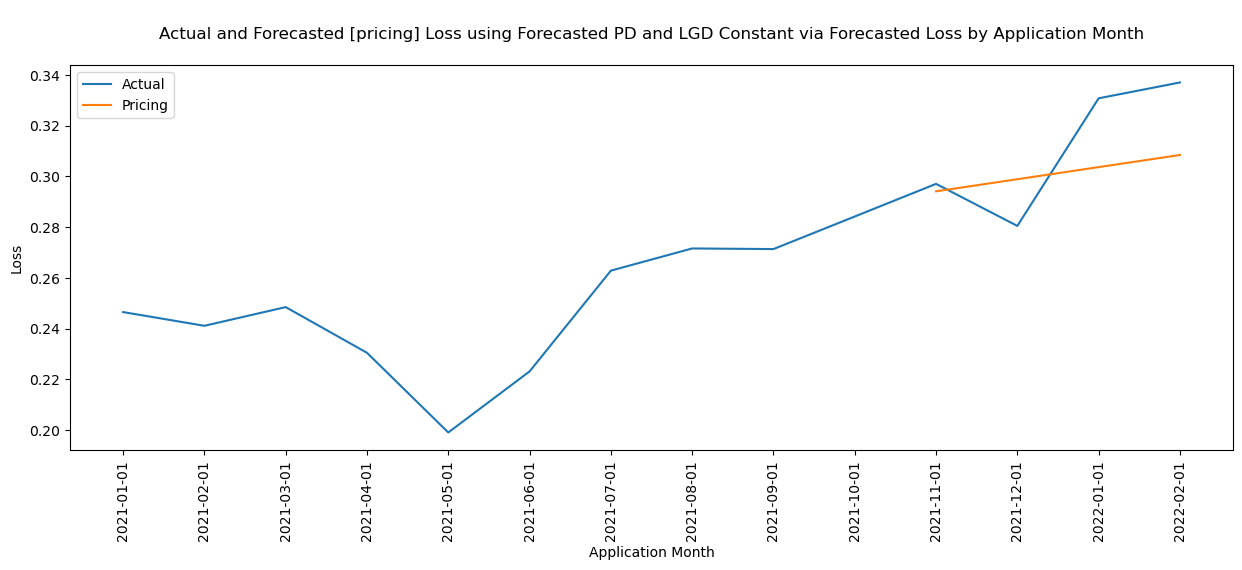

In [42]:
# plot
str_title = f"""
Actual and Forecasted [pricing] Loss using Forecasted PD and LGD Constant via Forecasted Loss by Application Month
"""
fig, ax = plt.subplots(figsize=(15,5))
ax.set_title(str_title)
ax.set_xlabel('Application Month')
ax.set_ylabel('Loss')
ax.plot(df_grouped['application_month'], df_grouped['target'], label='Actual')
ax.plot(df_grouped['application_month'], df_grouped['forecasted_pricing'], label='Pricing')
ax.set_xticklabels(df_grouped['application_month'], rotation=90)
plt.legend()
plt.show()

### Clean-up

In [43]:
list_str_filename = [
    'cls_model_preprocessing.pkl',
    'preprocessing.py',
]
for str_filename in list_str_filename:
    try:
        os.remove(str_filename)
    except:
        pass